# Goal: Fairness Metrics Computation
The goal of this notebook is given:
- a dataset D
- a target variable
- a sensible attribute
- a legittimate attribute (needed only for one specific metric)

it computes the statistical fairness metrics presented in Verma and Rubin paper https://dl.acm.org/doi/pdf/10.1145/3194770.3194776 + Aequitas metrics https://arxiv.org/pdf/1811.05577.pdf.

The running example is the Credit Score dataset https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk



## Only for Colab environment

In [1]:
#online for colab environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Import e Preprocessing

In [2]:
%cd /content/drive/MyDrive/USA/preprocessing/
from distribution_utils import *

/content/drive/MyDrive/USA/preprocessing


In [3]:
%cd /content/drive/MyDrive/USA/COMPAS

/content/drive/MyDrive/USA/COMPAS


## Load the dataset

In [7]:
dataset_path = 'cox-violent-parsed_filt.csv'
df=pd.read_csv(dataset_path)
df.head(10)

,id,name,first,last,sex,dob,age,age_cat,race,juv_fel_count,...,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,priors_count.1,event
0,1.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
1,2.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
2,3.0,michael ryan,michael,ryan,Male,06/02/1985,31,25 - 45,Caucasian,0,...,NaN,Risk of Recidivism,5,Medium,31/12/2014,Risk of Violence,2,Low,0,0
3,4.0,kevon dixon,kevon,dixon,Male,22/01/1982,34,25 - 45,African-American,0,...,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,27/01/2013,Risk of Violence,1,Low,0,1
4,5.0,ed philo,ed,philo,Male,14/05/1991,24,Less than 25,African-American,0,...,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,4,0
5,6.0,ed philo,ed,philo,Male,14/05/1991,24,Less than 25,African-American,0,...,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,4,0
6,7.0,ed philo,ed,philo,Male,14/05/1991,24,Less than 25,African-American,0,...,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,4,0
7,8.0,ed philo,ed,philo,Male,14/05/1991,24,Less than 25,African-American,0,...,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,4,0
8,9.0,ed philo,ed,philo,Male,14/05/1991,24,Less than 25,African-American,0,...,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,4,0
9,10.0,marcu brown,marcu,brown,Male,21/01/1993,23,Less than 25,African-American,0,...,NaN,Risk of Recidivism,8,High,13/01/2013,Risk of Violence,6,Medium,1,0


In [8]:
print(df.race.unique())

['Other' 'Caucasian' 'African-American' 'Hispanic' 'Asian'
 'Native American']


In [9]:
df.describe()

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,event
count,11001.00000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,17019.000000,17449.000000,18316.000000,6359.000000,0.0,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000
mean,5501.00000,34.019273,0.076873,4.997052,0.098439,0.124263,3.913191,4.302485,57.694596,0.414774,19.961629,NaN,0.073105,4.997052,4.022822,3.913191,0.044715
std,3175.85949,11.667811,0.464272,2.937569,0.517639,0.524537,5.299864,81.159881,317.994694,0.576449,74.139695,NaN,0.260317,2.937569,2.614189,5.299864,0.206683
min,1.00000,18.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-597.000000,0.000000,-1.000000,-1.000000,NaN,0.000000,-1.000000,-1.000000,0.000000,0.000000
25%,2751.00000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,2.000000,0.000000,0.000000
50%,5501.00000,31.000000,0.000000,5.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,5.000000,4.000000,2.000000,0.000000
75%,8251.00000,41.000000,0.000000,8.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,8.000000,6.000000,5.000000,0.000000
max,11001.00000,96.000000,20.000000,10.000000,13.000000,17.000000,43.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,43.000000,1.000000


In [10]:
print(df.columns)

Index(['id', 'name', 'first', 'last', 'sex', 'dob', 'age', 'age_cat', 'race',
       'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count',
       'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out',
       'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'violent_recid', 'is_violent_recid',
       'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc',
       'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'priors_count.1', 'event'],
      dtype='object')


## Inputs

In [11]:
feature_cols= df.columns

## Preprocessing

In [12]:
for c in feature_cols:
   print(c, (df[c] == '?').sum())

id 0
name 0
first 0
last 0
sex 0
dob 0
age 0
age_cat 0
race 0
juv_fel_count 0
decile_score 0
juv_misd_count 0
juv_other_count 0
priors_count 0
days_b_screening_arrest 0
c_jail_in 0
c_jail_out 0
c_days_from_compas 0
c_charge_degree 0
c_charge_desc 0
is_recid 0
r_charge_degree 0
r_days_from_arrest 0
r_offense_date 0
r_charge_desc 0
r_jail_in 0
violent_recid 0
is_violent_recid 0
vr_charge_degree 0
vr_offense_date 0
vr_charge_desc 0
type_of_assessment 0
decile_score.1 0
score_text 0
screening_date 0
v_type_of_assessment 0
v_decile_score 0
v_score_text 0
priors_count.1 0
event 0


In [13]:
df[feature_cols].isna().sum()

,0
id,7315
name,0
first,0
last,0
sex,0
dob,0
age,0
age_cat,0
race,0
juv_fel_count,0


In [14]:
df = df.drop(columns=['id', 'name', 'first', 'last', 'dob',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out',
       'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'violent_recid', 'age_cat',
       'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc',
       'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'priors_count.1', 'event'])
df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,is_violent_recid
0,Male,69,Other,0,1,0,0,0,0
1,Male,69,Other,0,1,0,0,0,0
2,Male,31,Caucasian,0,5,0,0,0,0
3,Male,34,African-American,0,3,0,0,0,1
4,Male,24,African-American,0,4,0,1,4,0


In [15]:
print(len(df))
df = df.dropna()
df.head()
print(len(df))

18316
18316


In [16]:
df['race'] = df['race'].replace({'African-American': 0, 'Asian': 1, 'Caucasian': 1, 'Hispanic': 2, 'Native American': 2, 'Other': 2})

<ipython-input-16-52614714198d>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['race'] = df['race'].replace({'African-American': 0, 'Asian': 1, 'Caucasian': 1, 'Hispanic': 2, 'Native American': 2, 'Other': 2})


In [17]:
df['sex'] = df['sex'].replace({'Female': 0, 'Male': 1})

<ipython-input-17-426cec34a599>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'Female': 0, 'Male': 1})


In [18]:
df.loc[df['age'].between(0, 25, 'both'), 'age'] = 0
df.loc[df['age'].between(25, 45, 'right'), 'age'] = 1
df.loc[df['age'].between(45, 100, 'right'), 'age'] = 2
df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,is_violent_recid
0,1,2,2,0,1,0,0,0,0
1,1,2,2,0,1,0,0,0,0
2,1,1,1,0,5,0,0,0,0
3,1,1,0,0,3,0,0,0,1
4,1,0,0,0,4,0,1,4,0


In [19]:
df.describe()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,is_violent_recid
count,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000
mean,0.815298,0.902763,0.594726,0.076873,4.997052,0.098439,0.124263,3.913191,0.073105
std,0.388066,0.676900,0.706842,0.464272,2.937569,0.517639,0.524537,5.299864,0.260317
min,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,2.000000,0.000000
75%,1.000000,1.000000,1.000000,0.000000,8.000000,0.000000,0.000000,5.000000,0.000000
max,1.000000,2.000000,2.000000,20.000000,10.000000,13.000000,17.000000,43.000000,1.000000


# Save processed dataset

In [ ]:
df.to_csv("compas-preprocessed.csv", sep=',', index=False, encoding='utf-8')

# Distribution Analysis

In [22]:
protected_attributes =['age', 'sex', 'race']
target = 'is_violent_recid'
dataset_path= 'compas-preprocessed.csv'
df=pd.read_csv(dataset_path)

['age']


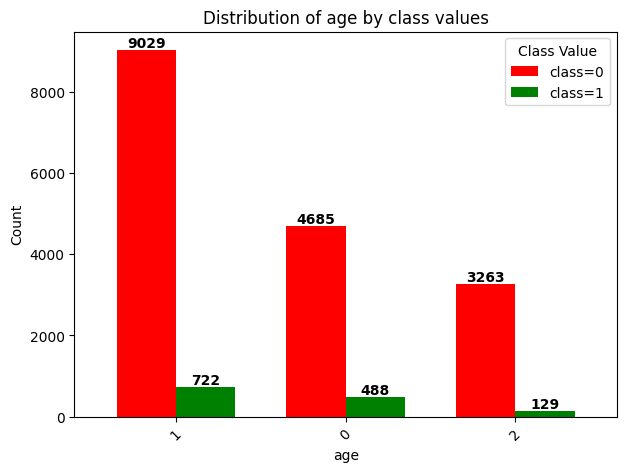

['sex']


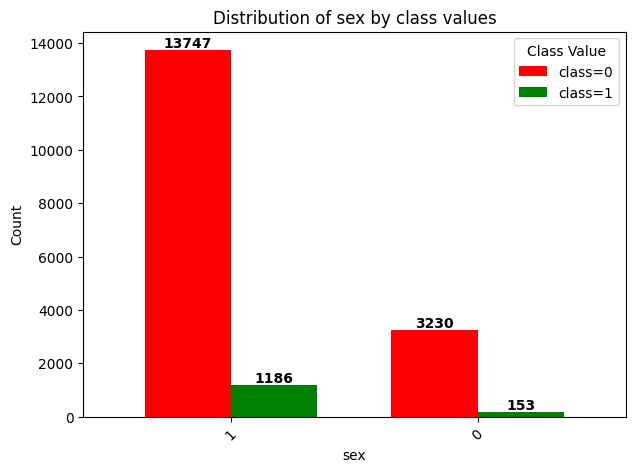

['race']


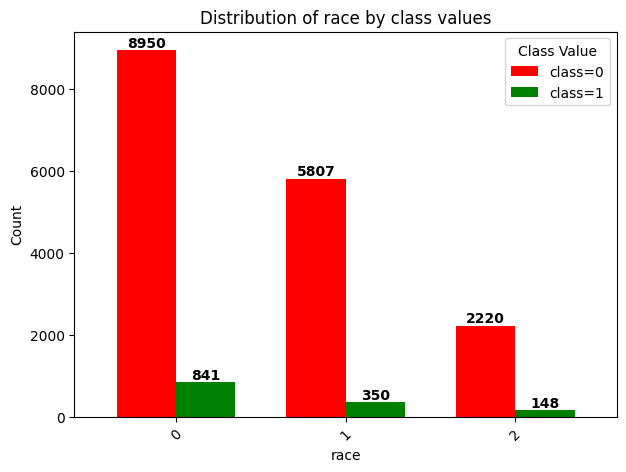

['age', 'sex']


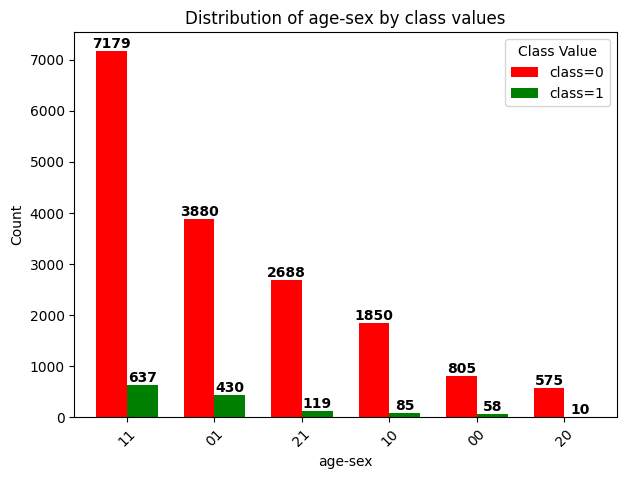

['age', 'race']


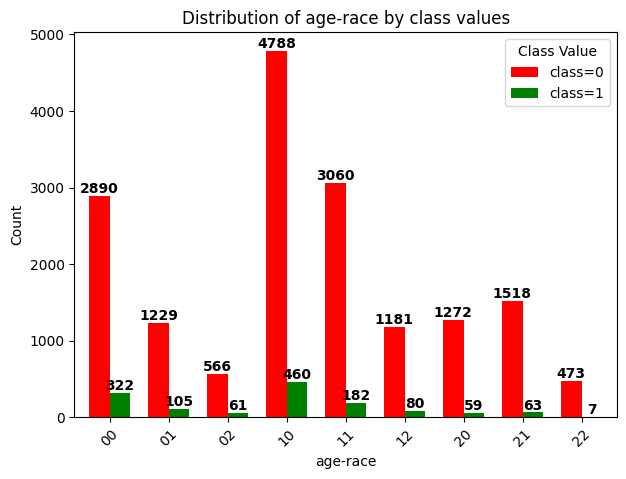

['sex', 'race']


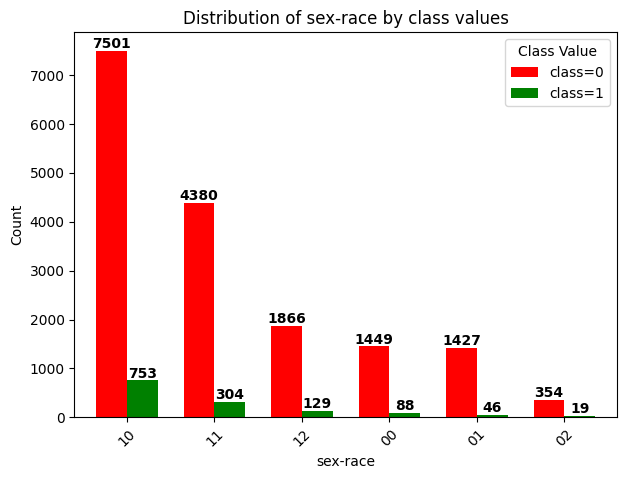

['age', 'sex', 'race']


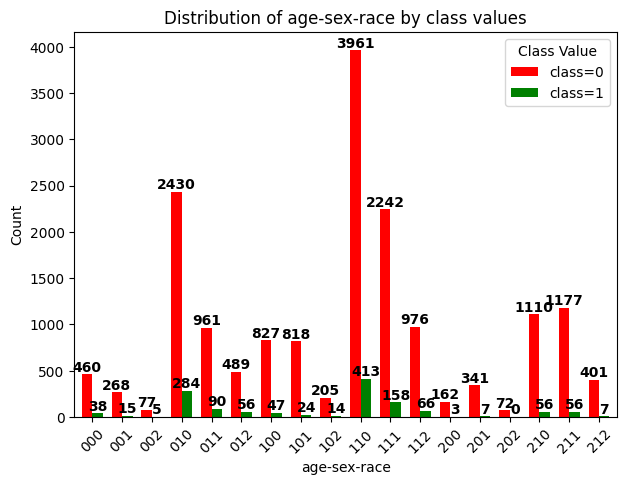

In [23]:
create_all_plots(dataset_path, protected_attributes, target)

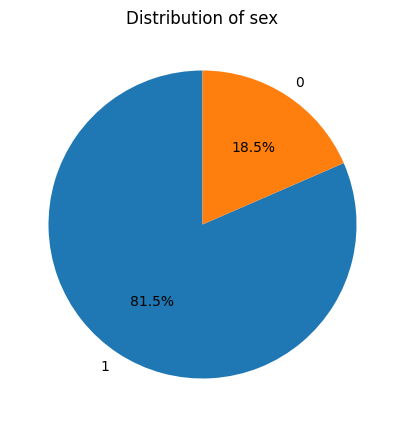

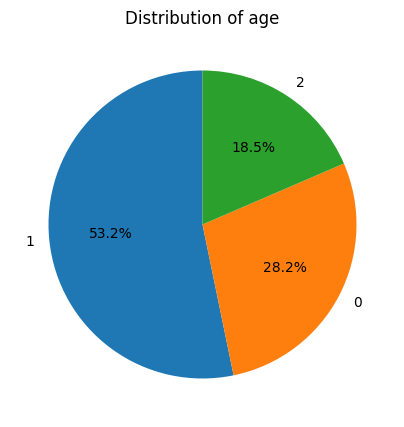

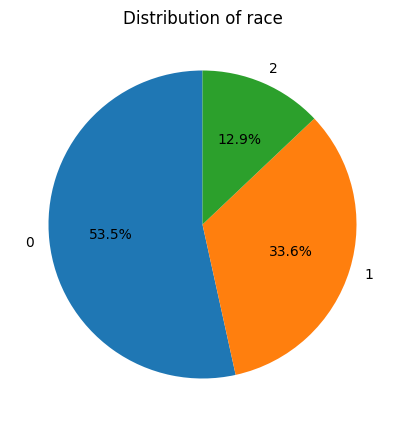

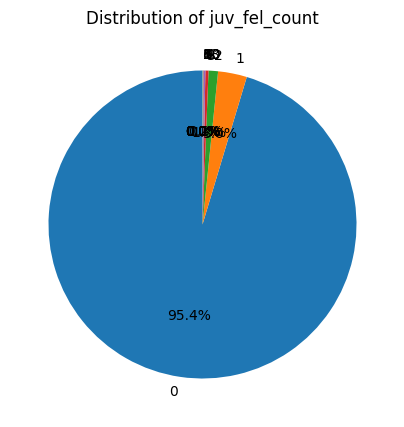

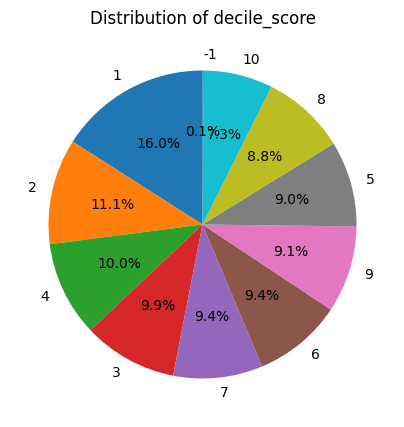

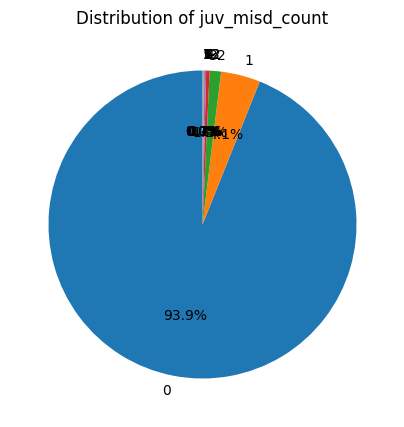

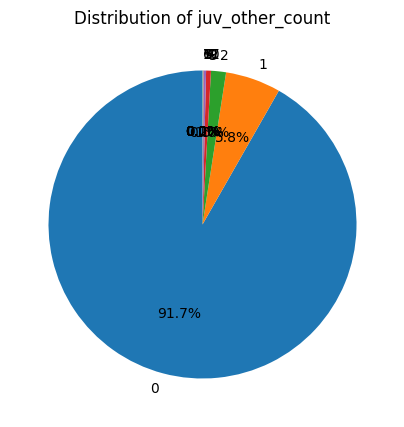

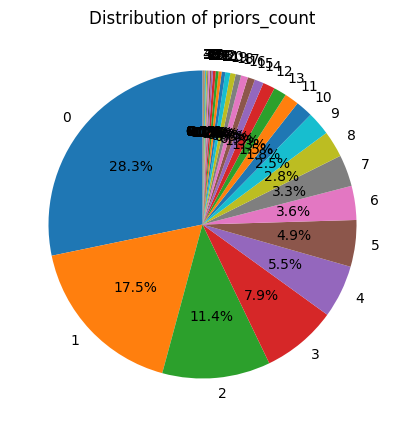

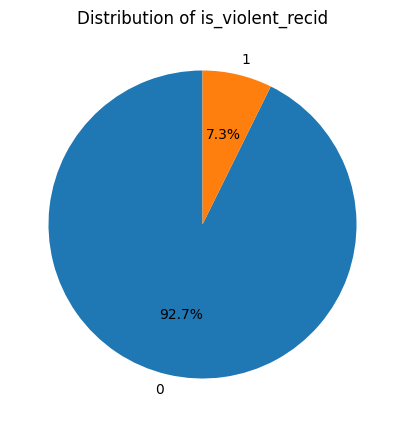

In [24]:
plot_occurencies(df)

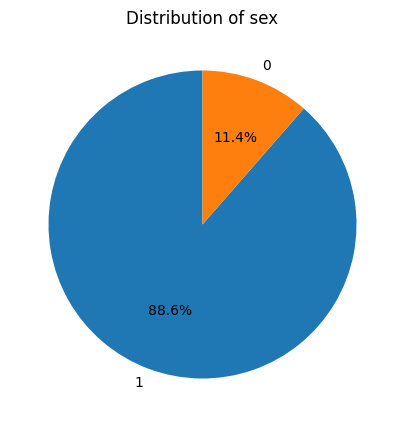

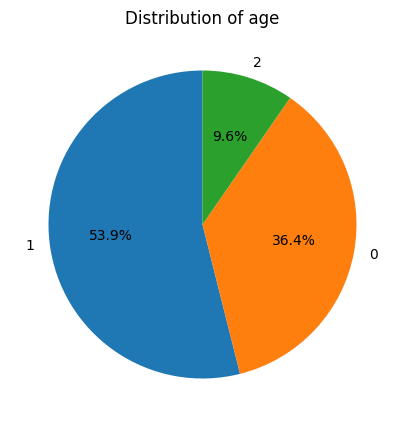

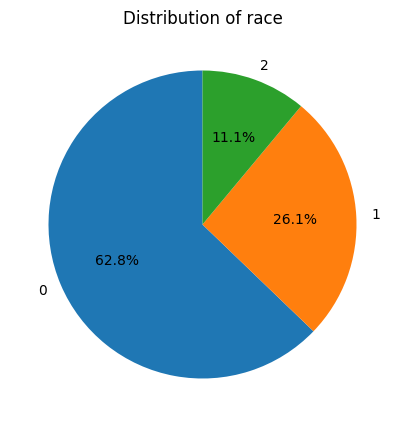

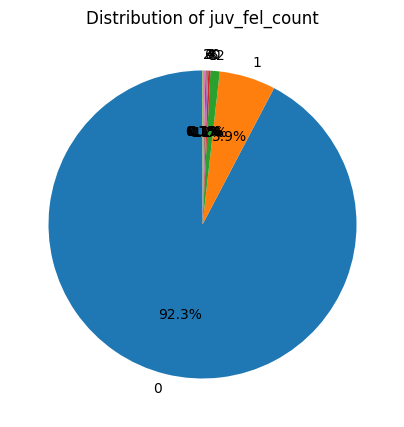

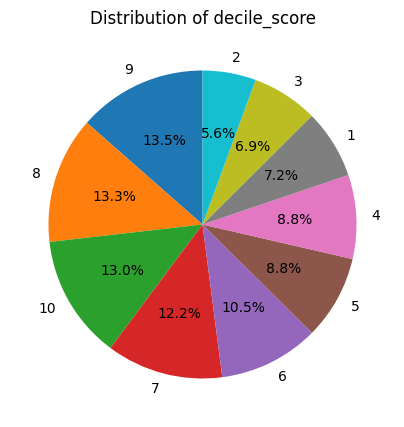

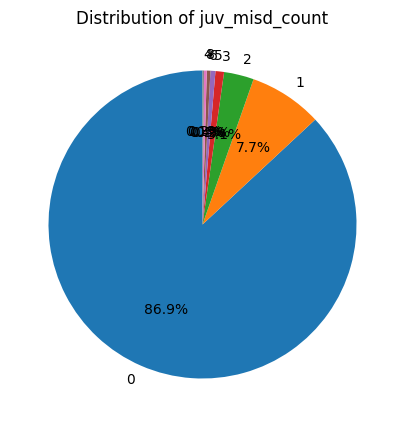

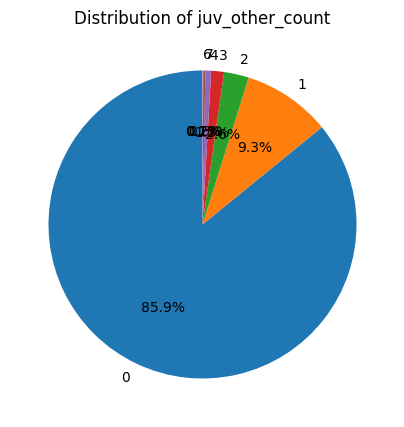

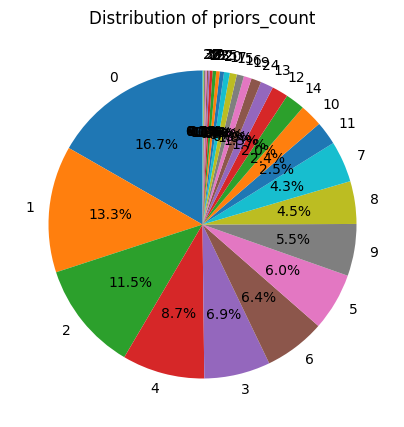

In [25]:
# Filter dataset where column tagert class == 1
filtered_df = df[df['is_violent_recid'] == 1]
plot_occurencies(filtered_df, 'is_violent_recid')

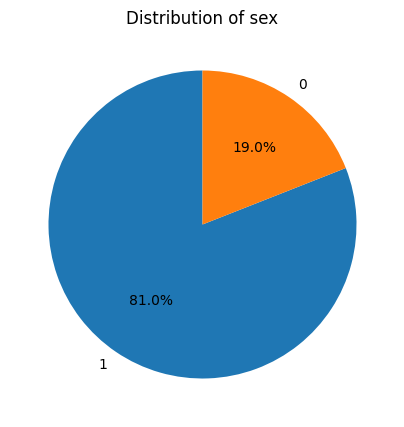

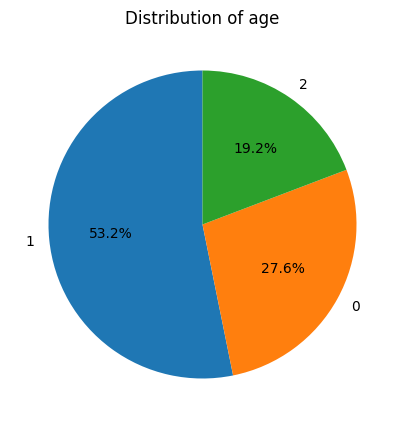

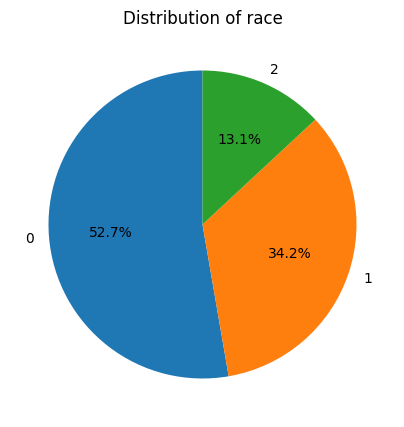

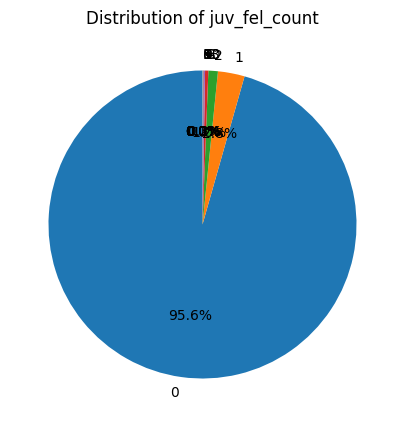

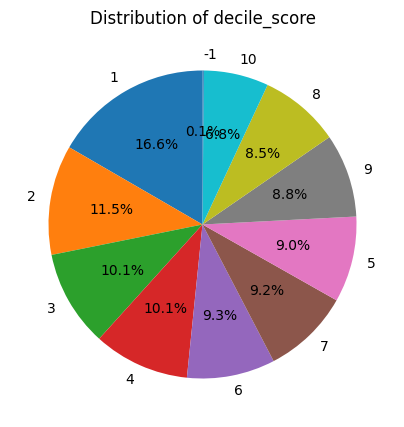

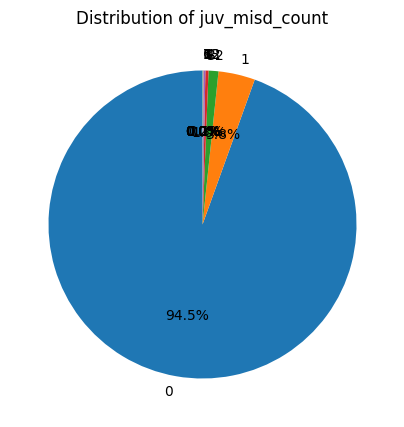

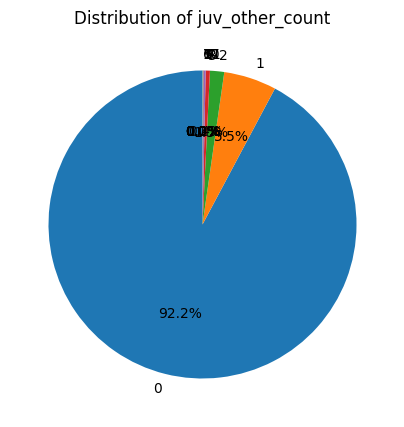

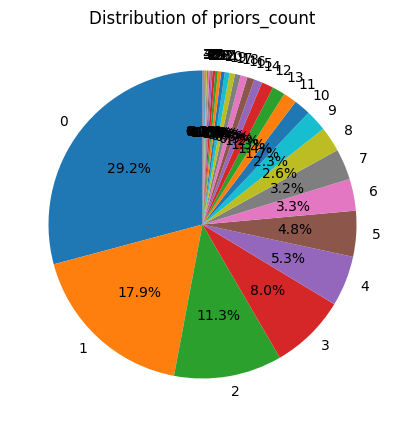

In [26]:
# Filter dataset where column target class == 0
filtered_df = df[df['is_violent_recid'] == 0]

plot_occurencies(filtered_df, 'is_violent_recid')